In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

In [2]:
add_error = 0.03
E1, theta1, data1 = 0.3686, 160, 'Altemus-1973' 
E2, theta2, data2 = 0.36, 140, 'Meziani-1984is'
Z = 26
A = 56

In [3]:
def prepare_df(filepath):
    Z = 26
    A = 56
    mass_nucleon = 0.938273
    mass_nucleus = A *0.931494
    alpha_fine = 1/137

    df = pd.read_csv(filepath)
    df["Veff"]=0.0089
    
    df["Eeff"]=df["E0"]+df["Veff"]
    df["nu"] = df["E0"]-df["Ep"]
    df["Ep_eff"]=df["Ep"]+df["Veff"]
    
    # calculate the kinematic variables:
    df["ThetaRad"]=df["theta"]*np.pi/180
    df["sin2(T/2)"]=(np.sin(df["ThetaRad"]/2))**2
    df["cos2(T/2)"]=(np.cos(df["ThetaRad"]/2))**2
    df["tan2(T/2)"]=(np.tan(df["ThetaRad"]/2))**2

    df["nuel"]=df["E0"]-df["E0"]/(1+2*df["E0"]*df["sin2(T/2)"]/mass_nucleus)
    df["Ex"] = df["nu"] - (df["E0"]-df["E0"]/(1+2*df["E0"]*df["sin2(T/2)"]/mass_nucleus))
    df["Q2"]=4*df["E0"]*(df["Ep"])*df["sin2(T/2)"]
    df["Q2eff"]=4*df["Eeff"]*df["Ep_eff"]*df["sin2(T/2)"]
    df["qv2"]=df["nu"]**2+df["Q2eff"]
    df["qv"]=np.sqrt(df["qv2"])
    df["w2"]=mass_nucleon**2+2*mass_nucleon*df["nu"]-df["Q2eff"]
    df["w2_O"]=mass_nucleon**2+2*mass_nucleon*df["nu"]-df["Q2"]    #print(df.head())
    
    return df

df1 = prepare_df("Sheren.csv")
df1.columns = df1.columns.str.strip()
#df1['ratio'] = pd.to_numeric(df1['ratio'], errors='coerce')

df1 = df1.dropna(subset=['ratio'])
filtered_df1 = df1[(df1['E0'] == E1) & (df1['theta'] == theta1)& (df1['dataSet'] == data1)].copy()

#ratio
filtered_df1['ratio'] = filtered_df1['xs']/filtered_df1['f1f221']
filtered_df1['ratio'] = pd.to_numeric(filtered_df1['ratio'], errors='coerce')

#ratio error
filtered_df1['ratio error'] = filtered_df1['err'] / filtered_df1['f1f221']
filtered_df1['ratio error'] = np.sqrt(filtered_df1['ratio error']**2 + (add_error * filtered_df1['ratio'])**2)

df2 = prepare_df("Sheren.csv")
df2.columns = df2.columns.str.strip()

df2['ratio'] = pd.to_numeric(df2['ratio'], errors='coerce')
df2 = df2.dropna(subset=['ratio']) 

filtered_df2 = df2[(df2['E0'] == E2) & (df2['theta'] == theta2)& (df2['dataSet'] == data2)].copy()

#ratio error
filtered_df2['ratio error'] = filtered_df2['err'] / filtered_df2['f1f221']
filtered_df2['ratio error'] = np.sqrt(filtered_df2['ratio error']**2 + (add_error * filtered_df2['ratio'])**2)

In [4]:
df1.to_csv('Sheren_Processed.csv',index=False)

0.6659642904238938
1.274055837815494
10 0


<function matplotlib.pyplot.show(close=None, block=None)>

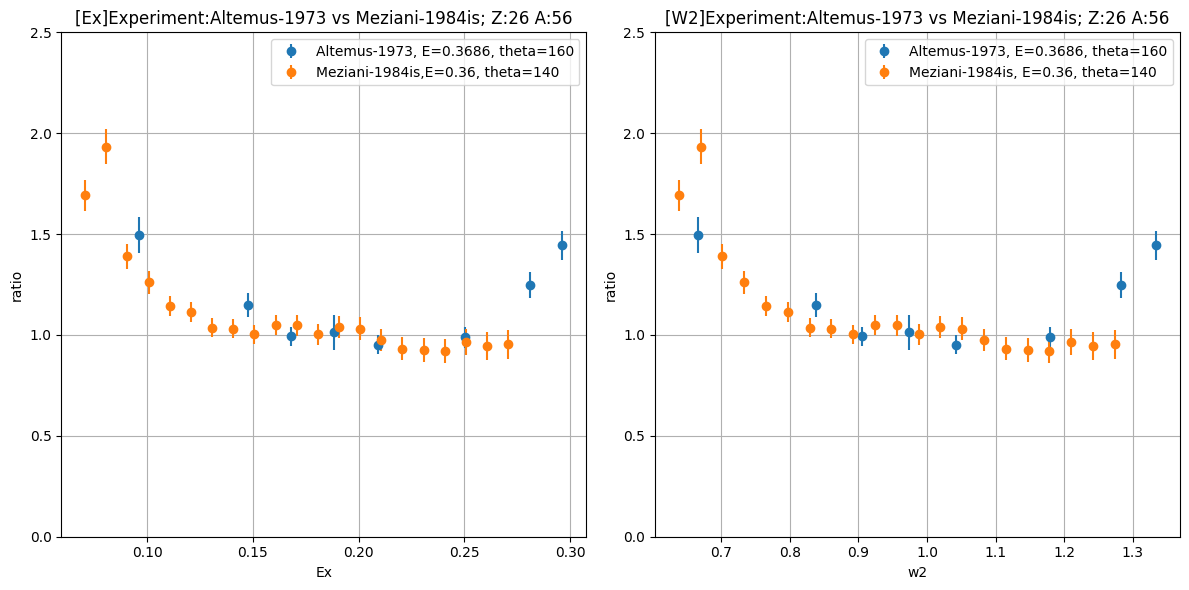

In [5]:
#change for selected points
min_ex = 0
max_ex = 10
# min_w2 = 1
# max_w2 = 1
min_w2 = max(min(filtered_df1['w2']), min(filtered_df2['w2']))
max_w2 = min(max(filtered_df1['w2']), max(filtered_df2['w2']))
print(min_w2)
print(max_w2)

#Filter
print (max_ex, min_ex)
range_df1 = filtered_df1[(filtered_df1['Ex'] > min_ex) & (filtered_df1['Ex'] < max_ex) & (filtered_df1['w2'] > min_w2) & (filtered_df1['w2'] < max_w2)].copy()
range_df2 = filtered_df2[(filtered_df2['Ex'] > min_ex) & (filtered_df2['Ex'] < max_ex) & (filtered_df2['w2'] > min_w2) & (filtered_df2['w2'] < max_w2)].copy()

fig, axs = plt.subplots(1, 2, figsize=(12, 6))
axs[0].errorbar(filtered_df1['Ex'], filtered_df1['ratio'], yerr=filtered_df1['ratio error'], fmt='o', label=f'{data1}, E={E1}, theta={theta1}')
axs[0].errorbar(filtered_df2['Ex'], filtered_df2['ratio'], yerr=filtered_df2['ratio error'], fmt='o', label=f'{data2},E={E2}, theta={theta2}')
axs[0].set_xlabel('Ex')
axs[0].set_ylabel('ratio')
axs[0].set_ylim(0,2.5)
axs[0].set_title(f"[Ex]Experiment:{data1} vs {data2}; Z:{Z} A:{A}")
axs[0].legend()
axs[0].grid(True)
axs[1].errorbar(filtered_df1['w2'], filtered_df1['ratio'], yerr=filtered_df1['ratio error'], fmt='o', label=f'{data1}, E={E1}, theta={theta1}')
axs[1].errorbar(filtered_df2['w2'], filtered_df2['ratio'], yerr=filtered_df2['ratio error'], fmt='o', label=f'{data2}, E={E2}, theta={theta2}')
axs[1].set_xlabel('w2')
axs[1].set_ylabel('ratio')
axs[1].set_ylim(0,2.5)
axs[1].set_title(f"[W2]Experiment:{data1} vs {data2}; Z:{Z} A:{A}")
axs[1].legend()
axs[1].grid(True)
plt.tight_layout()
#plt.savefig(file_path, dpi=300)
plt.show

W2: Best-fit scale factor k = 1.0032 ± 0.0346
Npoint1: 5
Npoint2: 19


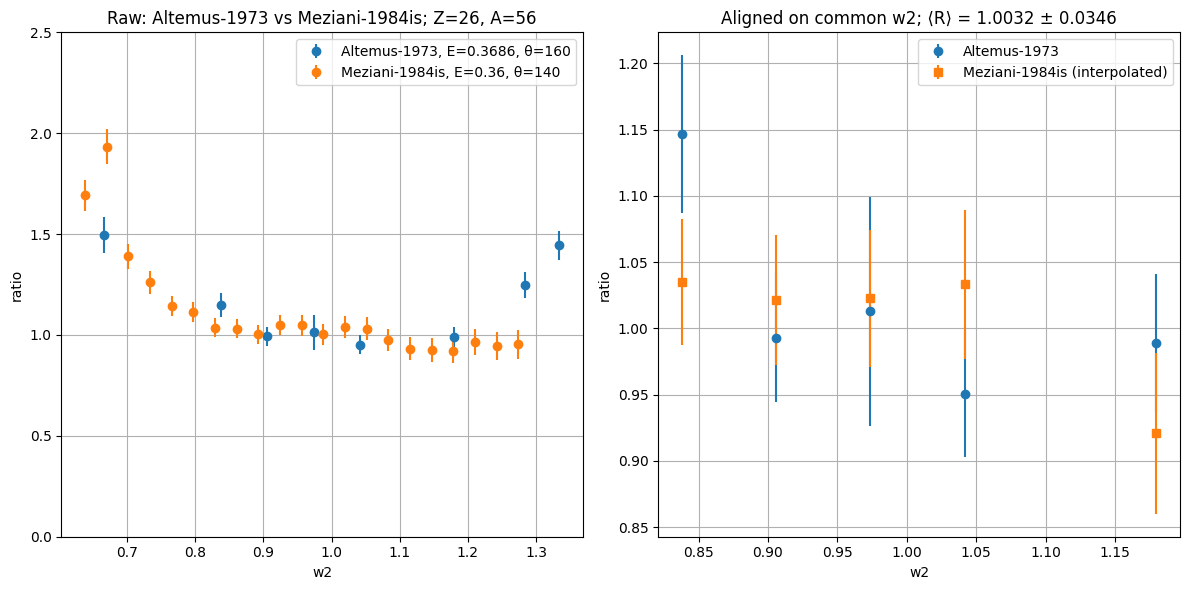

E=0.3686_theta=160_E=0.36_theta=140.png


In [6]:
save_directory = r"Plots"
os.makedirs(save_directory, exist_ok=True)
file_path = os.path.join(save_directory, f"E={E1}_theta={theta1}_E={E2}_theta={theta2}.png")

#W2 RATIO`
interp_ratio2 = np.interp(range_df1['w2'], range_df2['w2'], range_df2['ratio'])
interp_error2 = np.interp(range_df1['w2'], range_df2['w2'], range_df2['ratio error'])

ratio_vals = range_df1['ratio'] / interp_ratio2
ratio_errs = np.sqrt(
    (range_df1['ratio error'] / interp_ratio2)**2
    + (range_df1['ratio'] * interp_error2 / (interp_ratio2**2))**2
)

mask = (
    np.isfinite(ratio_vals)
    & np.isfinite(ratio_errs)
    & (ratio_errs > 0)
    & (interp_ratio2 != 0)
)
ratio_vals = ratio_vals[mask]
ratio_errs = ratio_errs[mask]

# --- after your mask is defined ---
# compute common arrays
w2_common       = range_df1['w2'].values[mask]
ratio1_common   = range_df1['ratio'].values[mask]
error1_common   = range_df1['ratio error'].values[mask]
ratio2_common   = interp_ratio2[mask]
error2_common   = interp_error2[mask]

if len(ratio_vals) == 0:
    print("No valid points remain after filtering; cannot compute scale factor.")
    k = np.nan
    k_err = np.nan
else:
    weights = 1.0 / (ratio_errs**2)
    sum_w   = np.sum(weights)
    if sum_w == 0:
        print("Sum of weights is zero; cannot compute scale factor.")
        k = np.nan
        k_err = np.nan
    else:
        k     = np.sum(ratio_vals * weights) / sum_w
        k_err = 1.0 / np.sqrt(sum_w)
    print(f"W2: Best-fit scale factor k = {k:.4f} ± {k_err:.4f}")

num_1 = len(range_df1['ratio'])
num_2 = len(range_df2['ratio'])
print(f"Npoint1: {num_1}")
print(f"Npoint2: {num_2}")

# now plot both on the same w2 grid
fig, axs = plt.subplots(1, 2, figsize=(12, 6))

# left: original unaligned for comparison
axs[0].errorbar(filtered_df1['w2'], filtered_df1['ratio'],yerr=filtered_df1['ratio error'], fmt='o',label=f'{data1}, E={E1}, θ={theta1}')
axs[0].errorbar(filtered_df2['w2'], filtered_df2['ratio'],yerr=filtered_df2['ratio error'], fmt='o',label=f'{data2}, E={E2}, θ={theta2}')
axs[0].set(xlabel='w2', ylabel='ratio', ylim=(0,2.5),title=f"Raw: {data1} vs {data2}; Z={Z}, A={A}")
axs[0].legend(); axs[0].grid(True)
# right: interpolated dataset2 vs dataset1 on aligned w2
axs[1].errorbar(w2_common, ratio1_common,yerr=error1_common, fmt='o',label=f'{data1}')
axs[1].errorbar(w2_common, ratio2_common,yerr=error2_common, fmt='s',label=f'{data2} (interpolated)')
axs[1].set(xlabel='w2', ylabel='ratio', title=f"Aligned on common w2; ⟨R⟩ = {k:.4f} ± {k_err:.4f}")
axs[1].legend(); axs[1].grid(True)
plt.tight_layout()

plt.savefig(file_path, dpi=300)
plt.show()
print(f"E={E1}_theta={theta1}_E={E2}_theta={theta2}.png")